# Reproduce Fig. 3

In [1]:
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
from numba import njit, prange

codedir = "../src/"

sys.path.append(os.path.abspath(codedir))

from Vlasov_integrators_thick_disk import *

from dimensionless_to_physical_units import *

from axisymmetric_stability import *

import smplotlib

In [2]:
from paper_case_points import (
    POINTS_THIN_DISKS as points_thin_disks,
    POINTS_THICK_DISKS as points_thick_disks,
    THIN_DISK_MARKERS as thin_disk_marker,
    THICK_DISK_MARKERS as thick_disk_marker,
    scatter_marker_size,
)

Kim and Ostriker : hg = 0.87, hs = 0.4

In [ ]:
def get_surface_densities(R, Qgas, Qstars, hg, hs, kxval, kyval, ti, tf, model , nt = 300):

    G=1
    kappa=1

    kx, ky, Sigma_g, Sigma_s, sigma_x, cssq , Omega, OortA \
    = \
    get_physical_densities_and_speed_of_sounds_from_rafikov_dimensionless_variables_for_paper(kxval,kyval,Qgas, Qstars, R, kappa=1, gamma = np.sqrt(2), ksigma = 1)
    if model == "star-gas":
        sim = Gas_plus_stars_integrator(
            kx=kx, kyc=ky, Sigma_g= Sigma_g, 
            Sigma_s=Sigma_s,
            kappa = 1, 
            Omega0 = Omega, 
            sigma_x = sigma_x,
            cssq = cssq,
            Hg=hg*np.sqrt(cssq)/kappa,
            Hs = hs*sigma_x/kappa,
            G=1
        )
        print(f"stability, Qg = {Qgas}, Qs = {Qstars}, hg = {hg}, hs = {hs} : ", test_stability_thick_disks(R, Qgas, Qstars, hg, hs))
    elif model == "two-fluid":
        sim = two_fluid_integrator(
            kx=kx, kyc=ky, Sigma_g= Sigma_g, 
            Sigma_s=Sigma_s,
            kappa = 1, 
            Omega0 = Omega, 
            sigma_x = sigma_x,
            cssq = cssq,
            Hg=hg*np.sqrt(cssq)/kappa,
            Hs = hs*sigma_x/kappa,
            G=1
        )

        print(f"stability, Qg = {Qgas}, Qs = {Qstars}, hg = {hg}, hs = {hs} two-fluid : ", test_stability_twofluid_thick_disks(R, Qgas, Qstars, hg, hs))
    else:
        raise ValueError(f"model = {model} is not available. Please select from [fluid-gas, two-fluid]")
    
    t_grid = np.linspace(ti, tf, nt)

    results = sim.solve(t_grid, fext_params={'delta': 0.0, 'amplitude' : 0}, impulse_params = {"t_0": ti, "Sigma_impluse" : 1})

    surface_densities_stellar = sim.get_stellar_surface_density(results, t_grid)
    surface_densities_gas = sim.get_gas_surface_density(results, t_grid)
    
    return t_grid[1:], surface_densities_gas, surface_densities_stellar

# Top Panel: Thin Disks

stability, Qg = 5.0, Qs = 1.4285714285714286, hg = 0.0, hs = 0.0 :  1
stability, Qg = 5.0, Qs = 1.4285714285714286, hg = 0.0, hs = 0.0 two-fluid :  1
stability, Qg = 5.0, Qs = 1.4285714285714286, hg = 0.0, hs = 0.0 :  1
stability, Qg = 5.0, Qs = 1.4285714285714286, hg = 0.0, hs = 0.0 two-fluid :  1
stability, Qg = 5.0, Qs = 1.4285714285714286, hg = 0.0, hs = 0.0 :  1
stability, Qg = 5.0, Qs = 1.4285714285714286, hg = 0.0, hs = 0.0 two-fluid :  1
stability, Qg = 1.4285714285714286, Qs = 5.0, hg = 0.0, hs = 0.0 :  1
stability, Qg = 1.4285714285714286, Qs = 5.0, hg = 0.0, hs = 0.0 two-fluid :  1
stability, Qg = 1.4285714285714286, Qs = 5.0, hg = 0.0, hs = 0.0 :  1
stability, Qg = 1.4285714285714286, Qs = 5.0, hg = 0.0, hs = 0.0 two-fluid :  1
stability, Qg = 1.4285714285714286, Qs = 5.0, hg = 0.0, hs = 0.0 :  1
stability, Qg = 1.4285714285714286, Qs = 5.0, hg = 0.0, hs = 0.0 two-fluid :  1
stability, Qg = 2.2, Qs = 2.2, hg = 0.0, hs = 0.0 :  1
stability, Qg = 2.2, Qs = 2.2, hg = 0.0, hs =

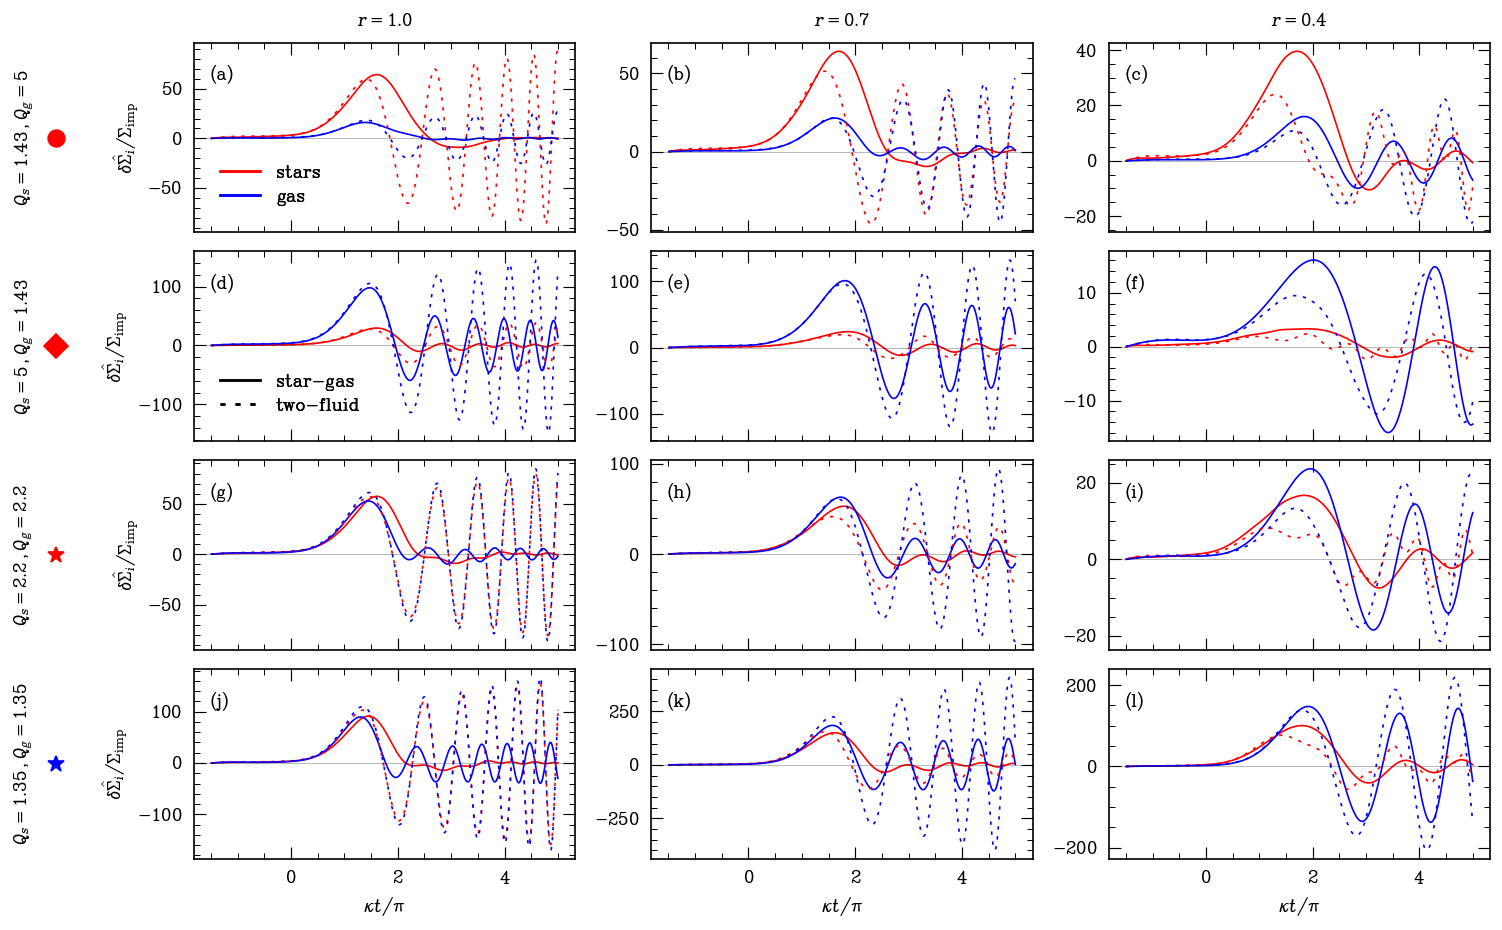

In [4]:
from matplotlib.lines import Line2D
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Swing amplification figure:
# fluid-gas + two-fluid together
# -----------------------------

R_values = [1.0, 0.7, 0.4]

kyval = 0.5
kxval = 0.0
ti = -3.0 * np.pi / 2.0
tf = 5.0 * np.pi
nt = 1000

TEXT_FONTSIZE = 12

rows = [
    {
        "point": points_thin_disks[2],
        "marker": thin_disk_marker[2],
        "marker_color": "red",
        "hg": 0.0,
        "hs": 0.0,
    },
    {
        "point": points_thin_disks[0],
        "marker": thin_disk_marker[0],
        "marker_color": "red",
        "hg": 0.0,
        "hs": 0.0,
    },
    {
        "point": points_thin_disks[1],
        "marker": thin_disk_marker[1],
        "marker_color": "red",
        "hg": 0.0,
        "hs": 0.0,
    },
    
    {
        "point": points_thick_disks[0],
        "marker": thick_disk_marker[0],
        "marker_color": "blue",
        "hg": 0.87,
        "hs": 0.4,
    },
]

# Color = component
component_styles = {
    "stars": {
        "color": "red",
        "label": "stars",
    },
    "gas": {
        "color": "blue",
        "label": "gas",
    },
}

# Line style = model
model_styles = {
    "star-gas": {
        "ls": "solid",
        "label": "star-gas",
    },
    "two-fluid": {
        "ls": "dotted",
        "label": "two-fluid",
    },
}

fig, axes = plt.subplots(
    len(rows),
    len(R_values),
    figsize=(13.5, 8.0),
    sharex=True,
)

panel_labels = list("abcdefghijkl")

# -----------------------------
# Plot panels
# -----------------------------

for i, row in enumerate(rows):
    Qs, Qg = row["point"]
    hg = row["hg"]
    hs = row["hs"]

    for j, Rval in enumerate(R_values):
        ax = axes[i, j]

        for model_name, model_style in model_styles.items():

            t_grid, Sigma_g, Sigma_s = get_surface_densities(
                R=Rval,
                Qgas=Qg,
                Qstars=Qs,
                hg=hg,
                hs=hs,
                kxval=kxval,
                kyval=kyval,
                ti=ti,
                tf=tf,
                model=model_name,
                nt=nt,
            )

            x = t_grid / np.pi

            # Stars: green
            ax.plot(
                x,
                np.real(Sigma_s),
                color=component_styles["stars"]["color"],
                lw=1.0,
                ls=model_style["ls"],
            )

            # Gas: purple
            ax.plot(
                x,
                np.real(Sigma_g),
                color=component_styles["gas"]["color"],
                lw=1.0,
                ls=model_style["ls"],
            )

        ax.axhline(0.0, color="black", lw=0.4, alpha=0.4)

        ax.text(
            0.04,
            0.88,
            rf"({panel_labels[i * len(R_values) + j]})",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=TEXT_FONTSIZE,
        )

        if i == 0:
            ax.set_title(
                rf"$r = {Rval}$",
                fontsize=TEXT_FONTSIZE,
            )

        if j == 0:
            ax.set_ylabel(
                r"$\delta \hat{\Sigma}_i/\Sigma_{\rm imp}$",
                fontsize=TEXT_FONTSIZE,
            )

        if i == len(rows) - 1:
            ax.set_xlabel(
                r"$\kappa t / \pi$",
                fontsize=TEXT_FONTSIZE,
            )

        ax.tick_params(labelsize=TEXT_FONTSIZE)

# -----------------------------
# Layout
# -----------------------------

fig.subplots_adjust(
    left=0.18,
    right=0.98,
    bottom=0.08,
    top=0.93,
    wspace=0.20,
    hspace=0.10,
)

# -----------------------------
# Row labels and explicit marker shapes
# -----------------------------

for i, row in enumerate(rows):
    Qs, Qg = row["point"]

    bbox = axes[i, 0].get_position()
    ymid = 0.5 * (bbox.y0 + bbox.y1)

    # Left to right:
    # marker -> Qg, Qs label -> plot
    marker_x = bbox.x0 - 0.085
    label_x = bbox.x0 - 0.055

    marker_artist = Line2D(
        [marker_x],
        [ymid],
        marker=row["marker"],
        linestyle="None",
        markersize=10,
        markerfacecolor=row["marker_color"],
        markeredgecolor=row["marker_color"],
        transform=fig.transFigure,
        clip_on=False,
        zorder=20,
    )
    fig.add_artist(marker_artist)

    fig.text(
        label_x - 0.05,
        ymid,
        rf"$Q_s = {Qs:.3g}\,, Q_g = {Qg:.3g}$",
        rotation=90,
        ha="center",
        va="center",
        fontsize=TEXT_FONTSIZE,
    )

# -----------------------------
# Legends inside selected panels
# -----------------------------

# Component/color legend: placed in panel (a)
ax_leg_component = axes[0, 0]

component_handles = [
    Line2D(
        [0],
        [0],
        color=component_styles["stars"]["color"],
        lw=1.5,
        ls="solid",
        label="stars",
    ),
    Line2D(
        [0],
        [0],
        color=component_styles["gas"]["color"],
        lw=1.5,
        ls="solid",
        label="gas",
    ),
]

legend_component = ax_leg_component.legend(
    handles=component_handles,
    loc="lower left",
    frameon=False,
    fontsize=TEXT_FONTSIZE,
)

ax_leg_component.add_artist(legend_component)


# Model/line-style legend: placed in panel (d)
ax_leg_model = axes[1, 0]

model_handles = [
    Line2D(
        [0],
        [0],
        color="black",
        lw=1.5,
        ls=model_styles["star-gas"]["ls"],
        label="star-gas",
    ),
    Line2D(
        [0],
        [0],
        color="black",
        lw=1.5,
        ls=model_styles["two-fluid"]["ls"],
        label="two-fluid",
    ),
]

legend_model = ax_leg_model.legend(
    handles=model_handles,
    loc="lower left",
    frameon=False,
    fontsize=TEXT_FONTSIZE,
)

ax_leg_model.add_artist(legend_model)

plt.savefig("./Figures/swing-amplification-single-wave.pdf")
plt.show()